In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install torch
!pip install torchvision
!pip install xgboost
!pip install dice_ml
!pip install lime
!pip install shap

In [1]:
import dice_ml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lime
import shap
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import partial_dependence, permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from xgboost import XGBClassifier

In [2]:
models = {
    "linear": {"Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)},
    "tree": {"Random Forest": RandomForestClassifier(random_state=42, n_estimators=100), 
             "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')}
}

# Loan approval system

Dataset source: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [3]:
data1 = pd.read_csv("./Datasets/LoanApproval.csv")
data1

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [4]:
data1.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [5]:
data1.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [6]:
#X = data1.drop(columns=['loan_status', 'loan_percent_income', 'previous_loan_defaults_on_file'])
X = data1.drop(columns=['loan_status'])
y = data1['loan_status']

In [7]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
feature_names = numerical_cols + categorical_cols

In [8]:
preprocessor_linear_data1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed_linear_data1 = preprocessor_linear_data1.fit_transform(X_train)
X_test_processed_linear_data1 = preprocessor_linear_data1.transform(X_test)
X_train_final_linear = pd.DataFrame(X_train_processed_linear_data1, columns=feature_names, index=X_train.index)
X_test_final_linear = pd.DataFrame(X_test_processed_linear_data1, columns=feature_names, index=X_test.index)

In [9]:
preprocessor_tree_data1 = ColumnTransformer(
    transformers=[
        ('num', "passthrough", numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed_tree_data1 = preprocessor_tree_data1.fit_transform(X_train)
X_test_processed_tree_data1 = preprocessor_tree_data1.transform(X_test)
X_train_final_tree = pd.DataFrame(X_train_processed_tree_data1, columns=feature_names, index=X_train.index)
X_test_final_tree = pd.DataFrame(X_test_processed_tree_data1, columns=feature_names, index=X_test.index)

In [10]:
tools_data1 = {
    "linear": (X_train_final_linear, y_train, X_test_final_linear, y_test),
    "tree": (X_train_final_tree, y_train, X_test_final_tree, y_test)
}

In [11]:
results_data1 = []
trained_models_data1 = {}

for name in models:
    for model_name, model in models[name].items():
        X_train_model, y_train_model, X_test_model, y_test_model = tools_data1[name]
        model.fit(X_train_model, y_train_model)
        y_pred = model.predict(X_test_model)
        accuracy = accuracy_score(y_test_model, y_pred)
        f1 = f1_score(y_test_model, y_pred)
        roc_auc = roc_auc_score(y_test_model, model.predict_proba(X_test_model)[:, 1])
        results_data1.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        })
        trained_models_data1[model_name] = model

performance_df_data1 = pd.DataFrame(results_data1).set_index("Model")
display(performance_df_data1)

/home/alexis/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [00:10:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,F1 Score,ROC AUC
Model,,,
Logistic Regression,0.890000,0.747578,0.948252
Random Forest,0.927333,0.825600,0.973080
XGBoost,0.933889,0.844769,0.977740


## Global explanation

### Permutation importance

In [12]:
data1.columns[12]

'previous_loan_defaults_on_file'

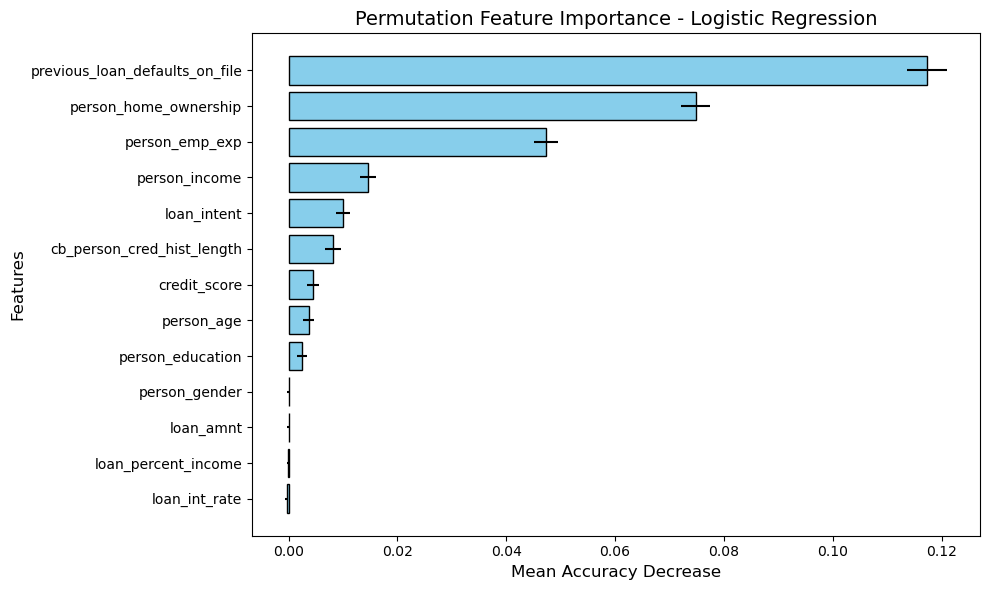

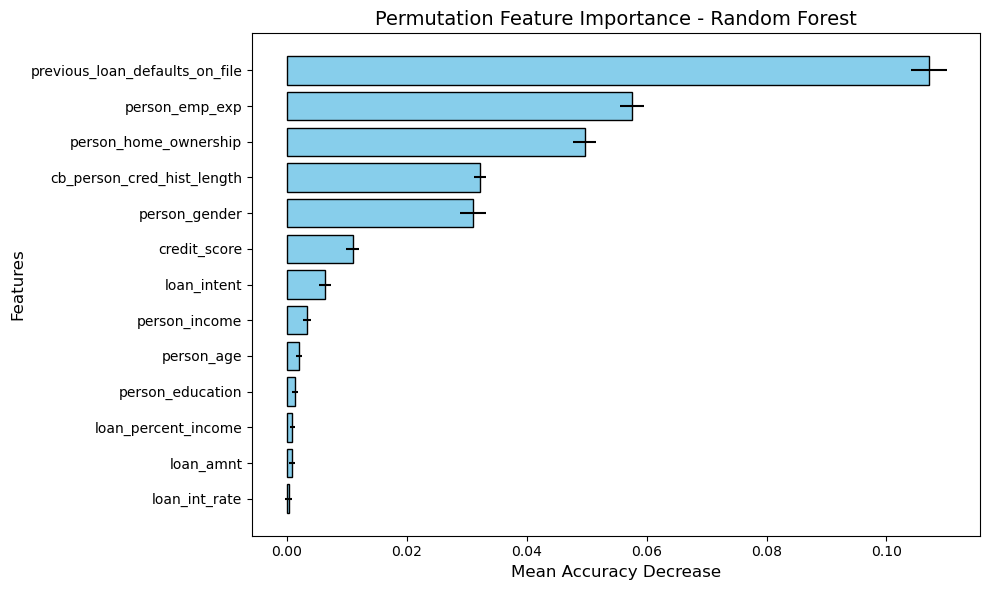

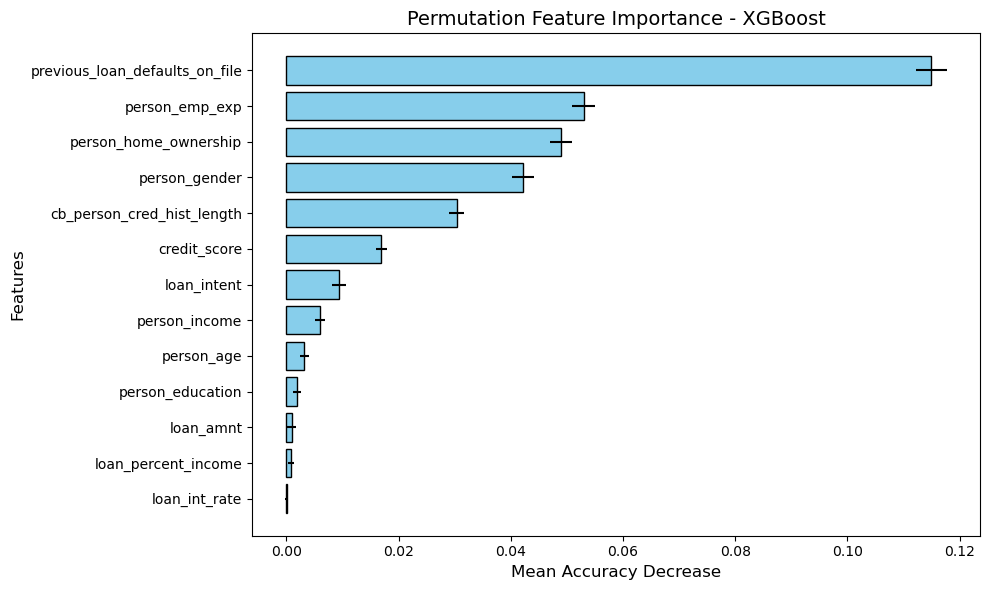

In [13]:
for name in models:
    for model_name in models[name]:
        trained_model = trained_models_data1[model_name]
        _, _, X_test_model, y_test_model = tools_data1[name]
        result = permutation_importance(trained_model, X_test_model, y_test_model, n_repeats=10, random_state=42)
        sorted_idx = result.importances_mean.argsort()
        feature_names = data1.columns[sorted_idx]
        means = result.importances_mean[sorted_idx]
        stds = result.importances_std[sorted_idx]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(feature_names, means, xerr=stds, align='center', color='skyblue', edgecolor='black')
        ax.set_title(f"Permutation Feature Importance - {model_name}", fontsize=14)
        ax.set_xlabel("Mean Accuracy Decrease", fontsize=12)
        ax.set_ylabel("Features", fontsize=12)
        plt.tight_layout()
        plt.show()

### Global SHAP

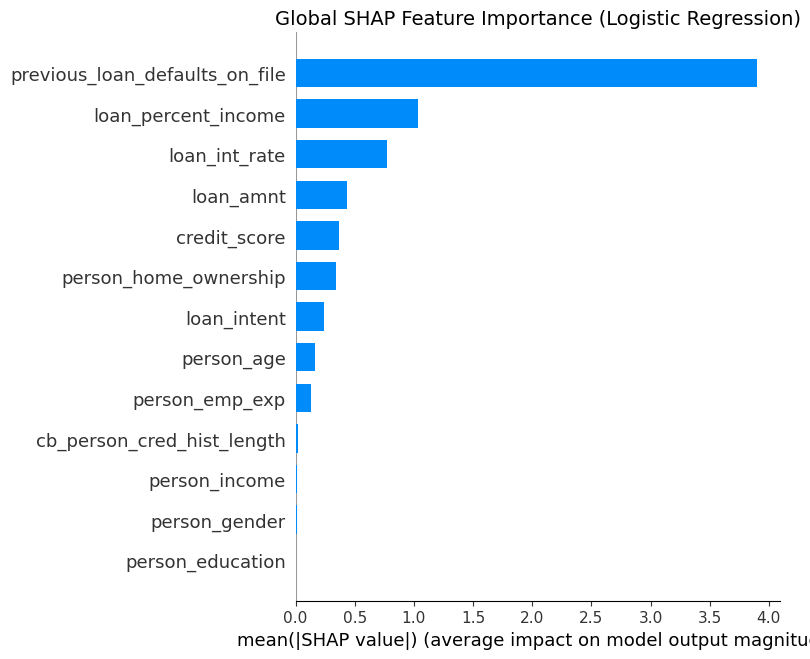

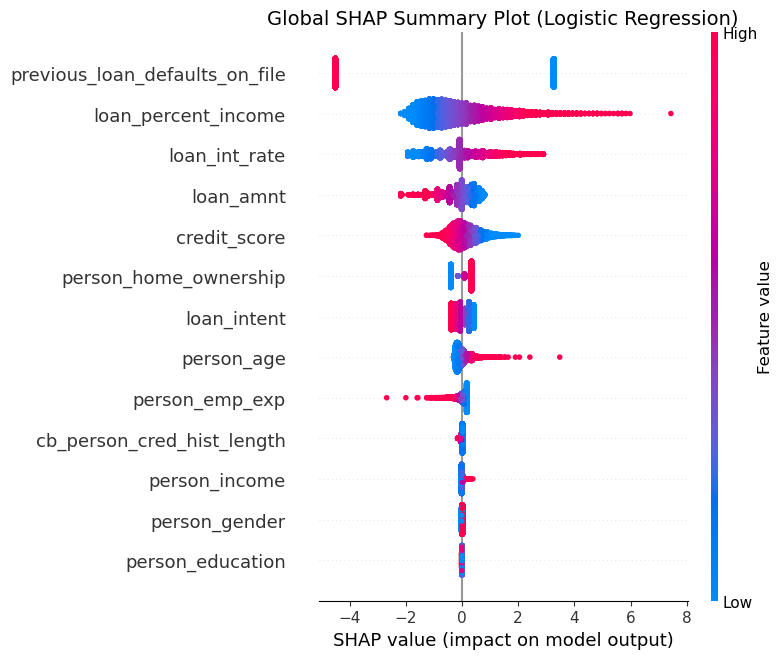

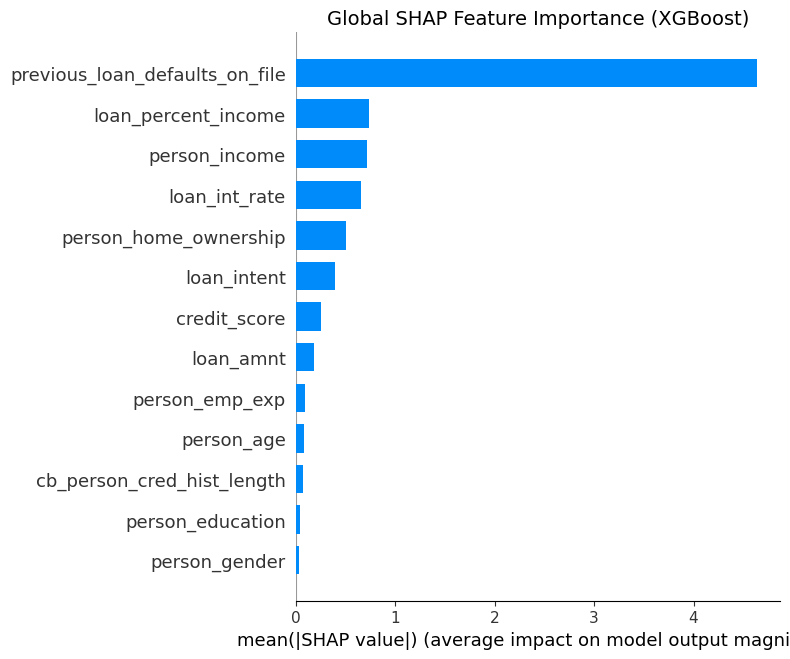

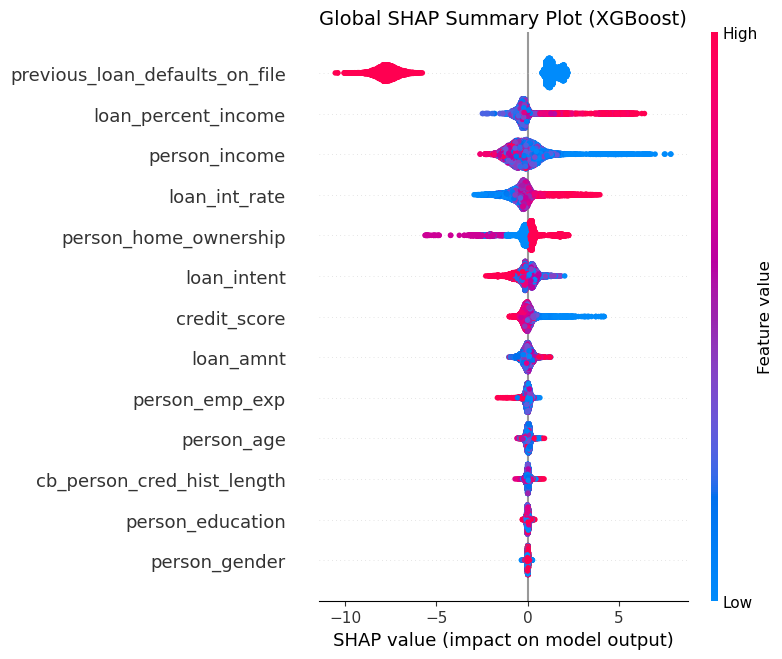

In [14]:
for name in models:
    for model_name in models[name]:
        if model_name != "Random Forest":
            model = trained_models_data1[model_name]
            X_train_model, _, X_test_model, y_test_model = tools_data1[name]
            if name == "linear":
                explainer = shap.LinearExplainer(model, X_train_model)
            else:
                explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_model)
        
            plt.figure(figsize=(10, 6))
            plt.title(f"Global SHAP Feature Importance ({model_name})", fontsize=14)
            shap.summary_plot(shap_values, X_test_model, plot_type="bar", show=False)
            plt.show()

            plt.figure(figsize=(10, 6))
            plt.title(f"Global SHAP Summary Plot ({model_name})", fontsize=14)
            shap.summary_plot(shap_values, X_test_model, show=False)
            plt.show()

### PDP/ICE

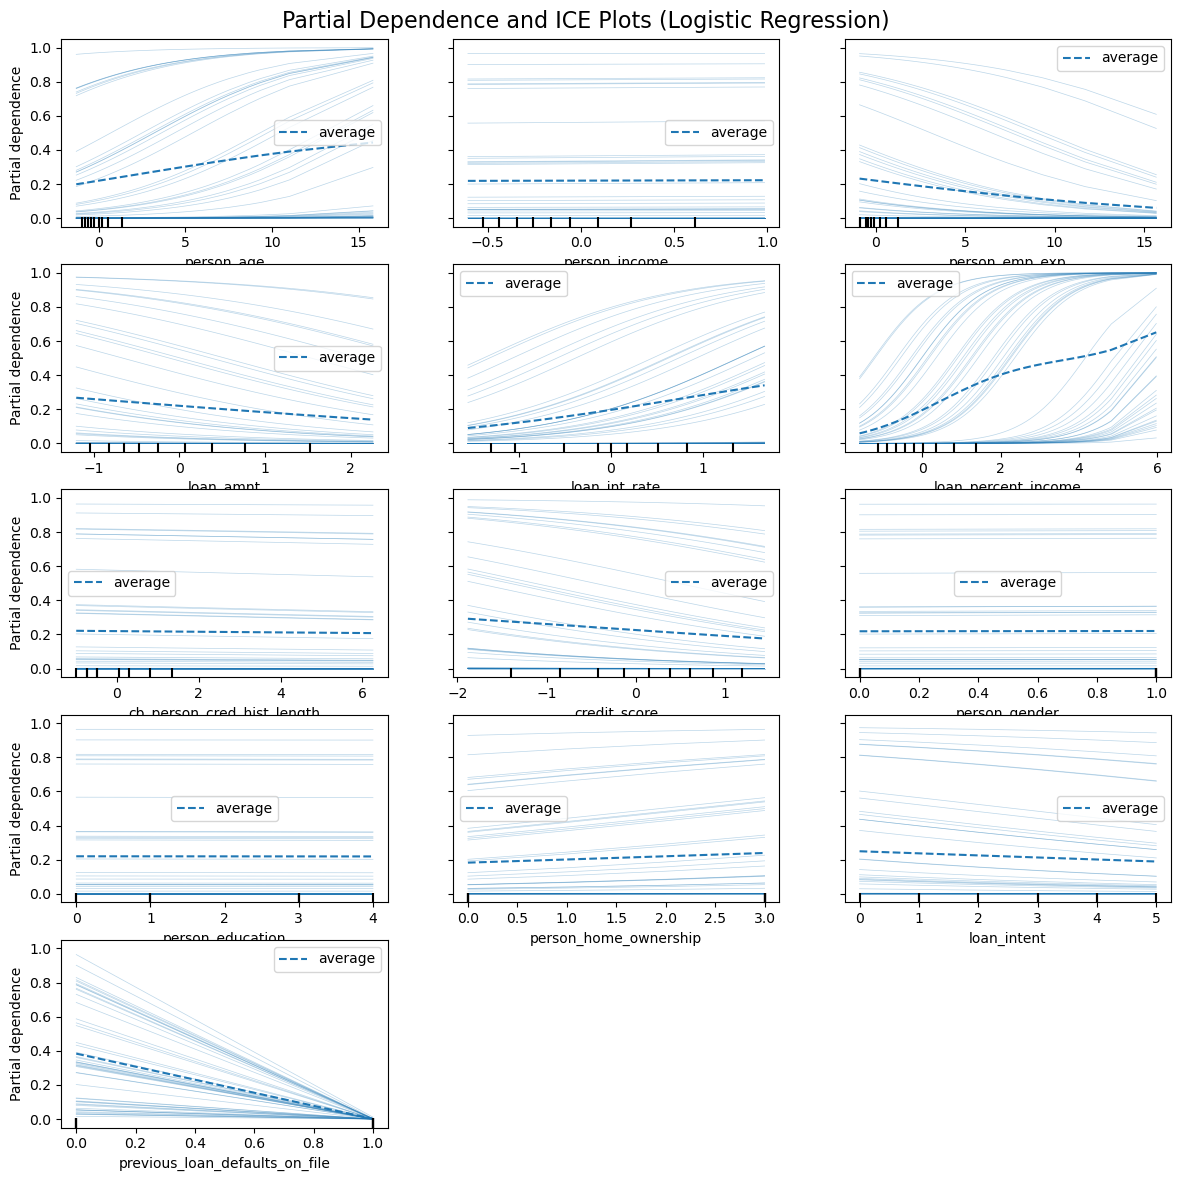

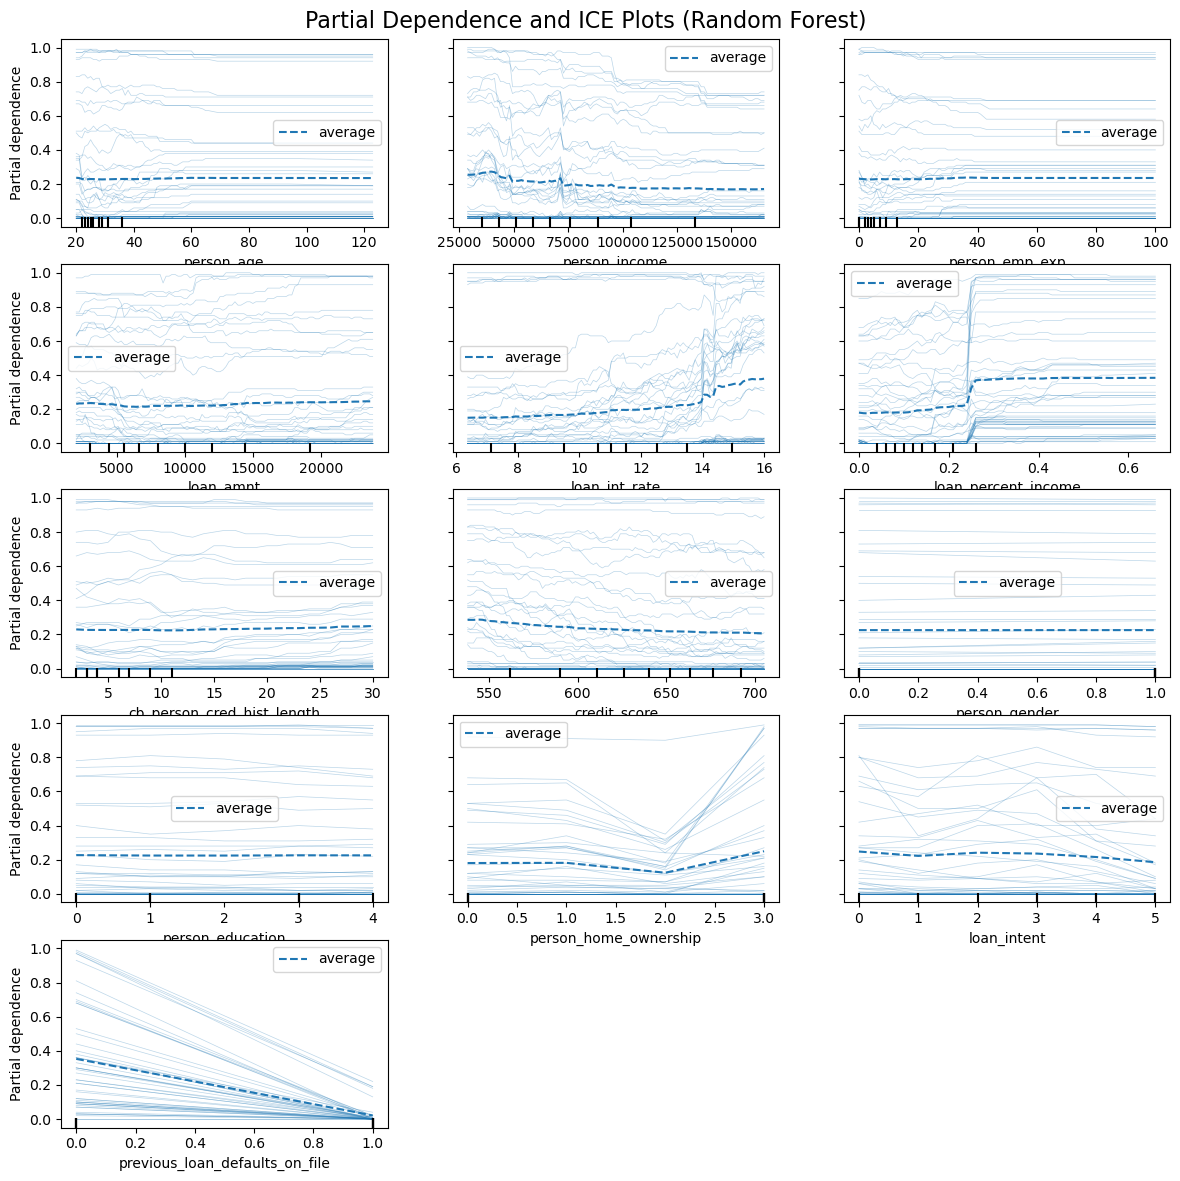

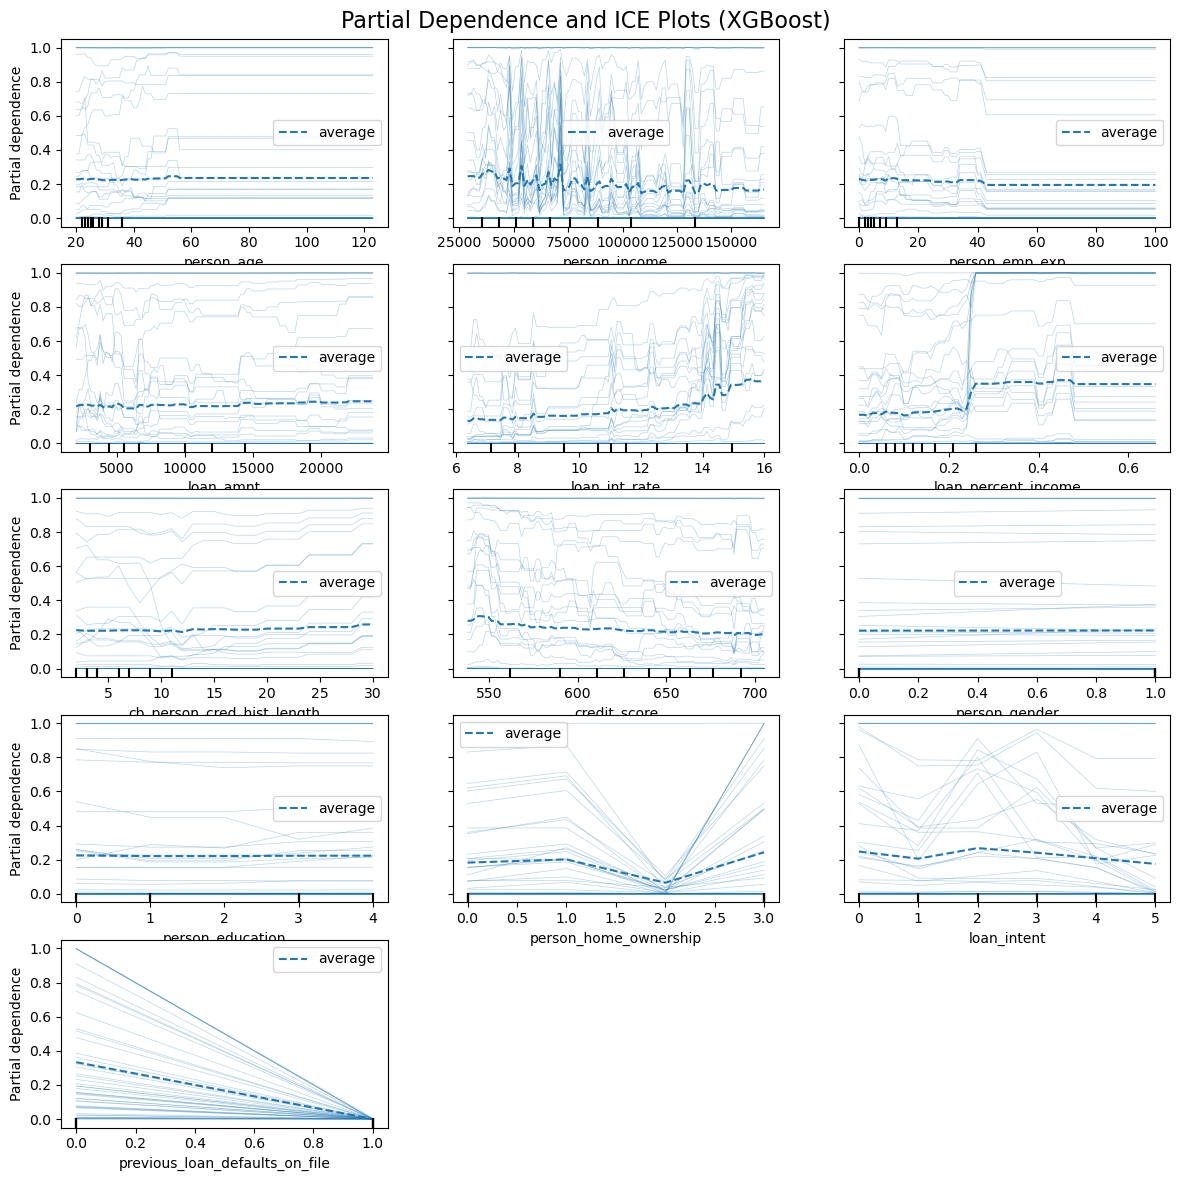

In [15]:
for name in models:
    for model_name in models[name]:
        model = trained_models_data1[model_name]
        _, _, X_test_model, _ = tools_data1[name]
        features_to_plot = X_test_model.columns
        fig, ax = plt.subplots(figsize=(12, 12))
        display = PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=X_test_model,
            features=features_to_plot,
            kind="both",       
            subsample=50,
            random_state=42,
            ax=ax
        )
        fig.suptitle(f"Partial Dependence and ICE Plots ({model_name})", fontsize=16)
        fig.tight_layout()
        plt.show()

## Local explanation

### Local explanation with LIME

person_age                        0.707106
person_income                     0.189549
person_emp_exp                    0.765411
loan_amnt                        -0.330054
loan_int_rate                    -1.659669
loan_percent_income              -0.685018
cb_person_cred_hist_length        1.075861
credit_score                     -0.629370
person_gender                     1.000000
person_education                  0.000000
person_home_ownership             0.000000
loan_intent                       1.000000
previous_loan_defaults_on_file    0.000000
Name: 37979, dtype: float64


/home/alexis/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


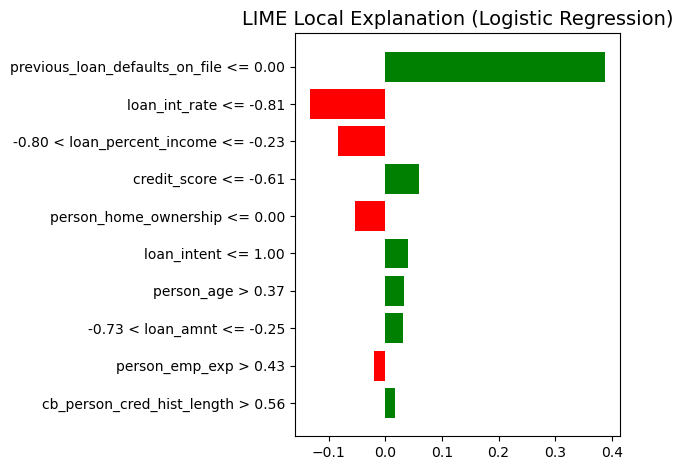

person_age                           32.00
person_income                     96865.00
person_emp_exp                       10.00
loan_amnt                          7500.00
loan_int_rate                         6.04
loan_percent_income                   0.08
cb_person_cred_hist_length           10.00
credit_score                        601.00
person_gender                         1.00
person_education                      0.00
person_home_ownership                 0.00
loan_intent                           1.00
previous_loan_defaults_on_file        0.00
Name: 37979, dtype: float64


/home/alexis/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


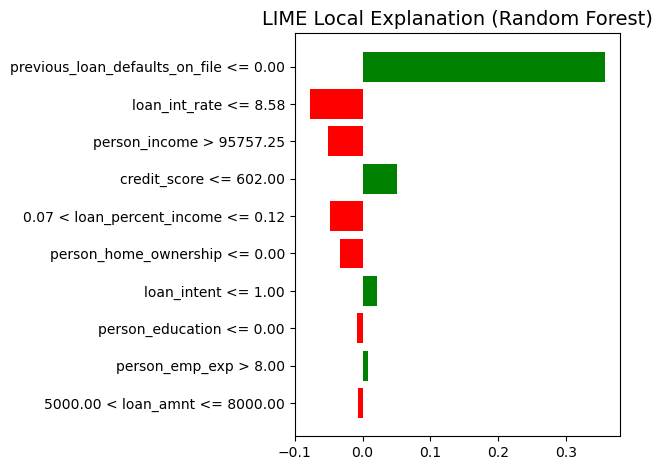

person_age                           32.00
person_income                     96865.00
person_emp_exp                       10.00
loan_amnt                          7500.00
loan_int_rate                         6.04
loan_percent_income                   0.08
cb_person_cred_hist_length           10.00
credit_score                        601.00
person_gender                         1.00
person_education                      0.00
person_home_ownership                 0.00
loan_intent                           1.00
previous_loan_defaults_on_file        0.00
Name: 37979, dtype: float64


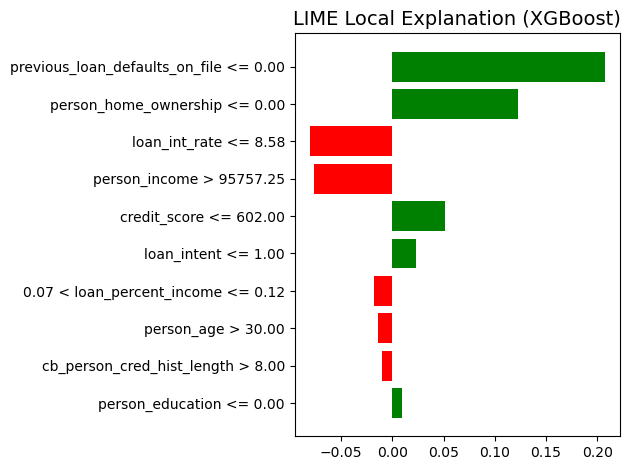

In [18]:
for name in models:
    for model_name in models[name]:
        model = trained_models_data1[model_name]
        X_train_model, y_train_model, X_test_model, _ = tools_data1[name]
        is_df = isinstance(X_train_model, pd.DataFrame)
        train_data = X_train_model.values if is_df else X_train_model
        feature_names = X_train_model.columns.tolist() if is_df else [f"Feature {i}" for i in range(train_data.shape[1])]
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=train_data,
            feature_names=feature_names,
            class_names=y_train_model.unique().tolist() if is_df else list(set(y_train_model)),
            mode='classification'
        )
        instance = X_test_model.iloc[0] if is_df else X_test_model[0]
        instance_values = instance.values if isinstance(instance, pd.Series) else instance
        
        exp = explainer.explain_instance(
            data_row=instance_values,
            predict_fn=model.predict_proba
        )
        
        print(instance)
        fig = exp.as_pyplot_figure()
        plt.title(f"LIME Local Explanation ({model_name})", fontsize=14)
        plt.tight_layout()
        plt.show()

### Local explanation with SHAP

### Local explanation with DiCE

In [19]:
for name in models:
    for model_name in models[name]:
        model = trained_models_data1[model_name]
        X_train_model, y_train_model, X_test_model, _ = tools_data1[name]
        if isinstance(X_train_model, pd.DataFrame):
            df_train = X_train_model.copy()
            df_train['target'] = y_train_model
            dice_data = dice_ml.Data(
                dataframe=df_train,
                continuous_features=X_train_model.columns.tolist(),
                outcome_name='target'
            )
            dice_model = dice_ml.Model(model=model, backend="sklearn")
            explainer_dice = dice_ml.Dice(dice_data, dice_model, method="random")
            query_instance = X_test_model.iloc[[0]]
            print(query_instance)
            
            try:
                dice_exp = explainer_dice.generate_counterfactuals(
                    query_instance, 
                    total_CFs=3,
                    desired_class="opposite"
                )
                dice_exp.visualize_as_dataframe(show_only_changes=True)
            except Exception as e:
                print("No available explanation")
        print("\n")

       person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
37979    0.707106       0.189549        0.765411  -0.330054      -1.659669   

       loan_percent_income  cb_person_cred_hist_length  credit_score  \
37979            -0.685018                    1.075861      -0.62937   

       person_gender  person_education  person_home_ownership  loan_intent  \
37979            1.0               0.0                    0.0          1.0   

       previous_loan_defaults_on_file  
37979                             0.0  


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  5.53it/s]

Query instance (original outcome : 0)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file,target
0,0.707106,0.189549,0.765411,-0.330054,-1.659669,-0.685018,1.075861,-0.62937,1.0,0.0,0.0,1.0,0.0,0


...

100%|██████████| 1/1 [00:00<00:00,  4.78it/s]

Query instance (original outcome : 0)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file,target
0,32.0,96865.0,10.0,7500.0,6.04,0.08,10.0,601.0,1.0,0.0,0.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file,target
0,-,-,-,-,17.94,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,15.98,-,-,-,-,-,-,0.8999999999999999,-,1.0
2,104.9,-,-,-,14.99,-,-,-,-,-,-,-,-,1.0
